In [40]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sys.path.append('../')
from src_experiment.paths import outputs
from src_experiment.estimate_quantities import ExperimentEvaluator
from geobin_py import Region, Tree

# Nr regions experiment

Aim is to replicate the experiment done in Hanin&Rolnick(?) where they plot 

In [41]:
lr = 0.001
dim = 2

def get_path(lr, dim, nr_neurons,seed=102):
    return outputs /f"wbc_nr_regions/dim{int(dim)}_[{nr_neurons}, {nr_neurons}, {nr_neurons}]_lr{lr}/seed_{int(seed)}.h5"

In [42]:
t1 = get_path(lr, dim, 3)
tr = Tree(t1, epoch=1)
Nrl1 = len(tr.get_regions_at_layer(4))
print(Nrl1)
print(len(tr.leaves))

  - Loading Epoch 1...
48
48


In [43]:
# def get_nr_regions_pr_layer_pr_epoch(path):
    

In [44]:
for seed in [102,103,104,105,106]:
    ev = ExperimentEvaluator(get_path(lr, dim, 3, seed))
    df_results = ev.evaluate_all()

Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [45]:
import pandas as pd

# 1. Extract TOTAL regions per epoch (rows) for each layer (columns)
total_regions_matrix = df_results.pivot(
    index="epoch", 
    columns="layer_idx", 
    values="total_regions"
)

# 2. Extract POPULATED regions per epoch (rows) for each layer (columns)
populated_regions_matrix = df_results.pivot(
    index="epoch", 
    columns="layer_idx", 
    values="populated_regions"
)

print("Total Regions per Layer over Epochs:")
print(total_regions_matrix.head())

Total Regions per Layer over Epochs:
layer_idx  1   2   3   4
epoch                   
0          7  22  42  46
1          7  22  42  46
2          7  22  42  46
3          7  22  42  46
4          7  22  41  45


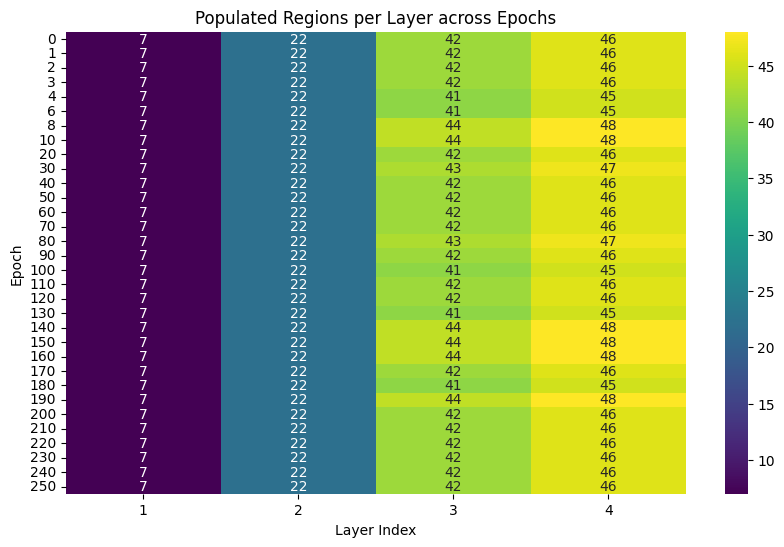

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(total_regions_matrix, cmap="viridis", annot=True, fmt="g")
plt.title("Populated Regions per Layer across Epochs")
plt.ylabel("Epoch")
plt.xlabel("Layer Index")
plt.show()

In [47]:
import pandas as pd

all_dfs = []
seeds = [102, 103, 104, 105, 106]

for seed in seeds:
    print(f"\n--- Evaluating Seed {seed} ---")
    ev = ExperimentEvaluator(get_path(lr, dim, 3, seed))
    df_results = ev.evaluate_all()
    
    # Optional: Tag the dataframe with its seed before appending
    df_results['seed'] = seed 
    all_dfs.append(df_results)

# 1. Combine all dataframes into one large dataframe
combined_df = pd.concat(all_dfs, ignore_index=True)

# 2. Group by the epoch and layer, then calculate the mean
mean_df = combined_df.groupby(['epoch', 'layer_idx']).mean().reset_index()

# 3. Drop the 'seed' column from the aggregated dataframe since a "mean seed" isn't useful
mean_df = mean_df.drop(columns=['seed'])




--- Evaluating Seed 102 ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
P

In [48]:
print("\nMean DataFrame:")
print(mean_df.head())


Mean DataFrame:
   epoch  layer_idx    I(Y;W)    I(X;W)  total_regions  populated_regions
0      0          1  0.074285  0.596293            7.0                3.6
1      0          2  0.153729  0.969802           19.0                5.2
2      0          3  0.157941  1.046431           35.6                6.0
3      0          4  0.186790  1.214284           46.6                7.0
4      1          1  0.083180  0.557235            7.0                3.6


In [49]:
last_layer_idx = mean_df['layer_idx'].max()

# Create a Series where the index is the 'epoch' and the values are 'total_regions'
regions_series = mean_df[mean_df['layer_idx'] == last_layer_idx].set_index('epoch')['total_regions']

print(regions_series)

# If you ever need it as a standard Python dictionary:
# regions_dict = regions_series.to_dict()

epoch
0      46.6
1      46.6
2      47.4
3      47.2
4      46.6
6      47.8
8      50.6
10     52.0
20     50.6
30     51.6
40     53.6
50     54.8
60     54.2
70     54.8
80     61.4
90     62.2
100    61.6
110    61.0
120    62.0
130    62.0
140    63.4
150    63.6
160    63.6
170    63.2
180    62.2
190    59.4
200    57.0
210    56.4
220    54.8
230    55.0
240    56.2
250    53.8
Name: total_regions, dtype: float64


In [50]:
# # Assuming 'combined_df' is already created from the loop above
# metrics_to_aggregate = ['I(Y;W)', 'I(X;W)', 'total_regions', 'populated_regions']

# # Calculate both mean and std for your metrics
# agg_df = combined_df.groupby(['epoch', 'layer_idx'])[metrics_to_aggregate].agg(['mean', 'std']).reset_index()

# # Flatten the multi-level columns created by .agg() (e.g., 'I(Y;W)_mean', 'I(Y;W)_std')
# agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]

# print("\nAggregated DataFrame (Mean & Std):")
# print(agg_df.head())

In [51]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Seaborn will automatically aggregate the seeds and plot the mean with error bands!
# sns.lineplot(data=combined_df, x="epoch", y="total_regions", hue="layer_idx", palette="viridis")
# plt.title("I(X;W) over Epochs (Averaged across seeds)")
# plt.show()

In [52]:
import pandas as pd

def get_mean_last_layer_regions(lr, dim, nr_neurons, seeds=None):
    """
    Evaluates experiments across multiple seeds for a specific set of hyperparameters.
    Returns a Pandas Series containing the mean 'total_regions' for the last layer, 
    indexed by epoch.
    """
    if seeds is None:
        seeds = [102, 103, 104, 105, 106]
        
    all_dfs = []
    
    for seed in seeds:
        print(f"--- Processing Seed {seed} (lr={lr}, dim={dim}, neurons={nr_neurons}) ---")
        
        # 1. Get the path using your custom function
        h5_path = get_path(lr, dim, nr_neurons, seed)
        
        # 2. Evaluate the experiment
        evaluator = ExperimentEvaluator(h5_path)
        df_results = evaluator.evaluate_all()
        
        all_dfs.append(df_results)
        
    # 3. Combine all runs into a single DataFrame
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # 4. Group by epoch and layer to get the mean across all seeds
    mean_df = combined_df.groupby(['epoch', 'layer_idx']).mean().reset_index()
    
    # 5. Identify the last layer
    last_layer_idx = mean_df['layer_idx'].max()
    
    # 6. Filter for the last layer and convert to a Series indexed by epoch
    last_layer_series = (mean_df[mean_df['layer_idx'] == last_layer_idx]
                         .set_index('epoch')['total_regions'])
    
    last_layer_series.name = f"Mean_Regions_L{last_layer_idx}_lr{lr}"
    
    print(f"\n✅ Finished processing. Extracted mean regions for Layer {last_layer_idx}.")
    return last_layer_series / (nr_neurons*3) # 3-layered networks

In [53]:
# Extract the series
regions_series = get_mean_last_layer_regions(lr=0.01, dim=2, nr_neurons=3)

# Print the final result
print("\nMean Total Regions in Final Layer per Epoch:")
print(regions_series)

--- Processing Seed 102 (lr=0.01, dim=2, neurons=3) ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...

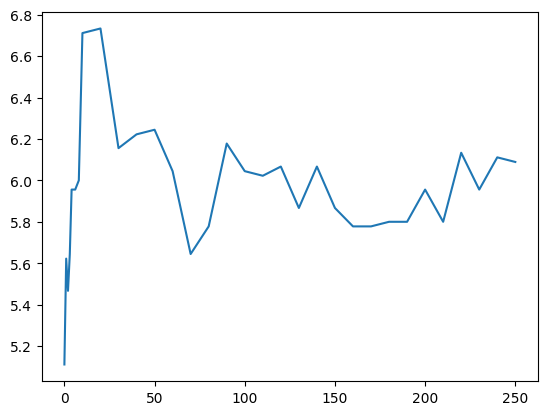

In [54]:
plt.plot(regions_series)

In [39]:
def plot_regions_pr_neuron(dim, lr):
    fig, ax = plt.subplots()

    for nr_neurons in [3,4,5,6,7]:
        regions_series = get_mean_last_layer_regions(lr=lr, dim=dim, nr_neurons=nr_neurons)
        ax.plot(regions_series, label=f"n={nr_neurons}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Regions pr neuron")
    fig.suptitle(f"Nr neurons for WBC data. Input dim: {dim}, lr: {lr}")
    plt.legend()
    plt.show()


--- Processing Seed 102 (lr=0.01, dim=2, neurons=3) ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...

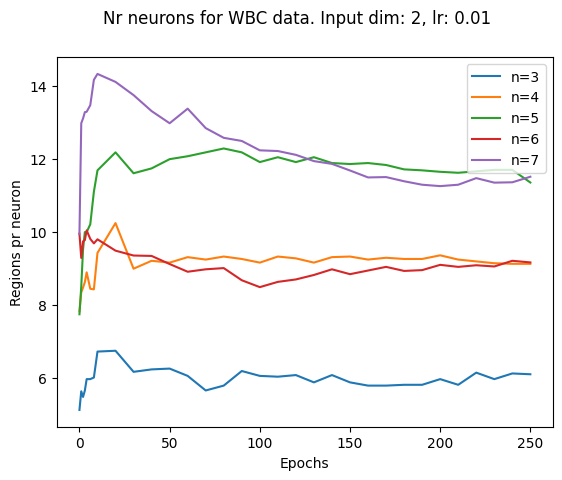

In [55]:
plot_regions_pr_neuron(2, 0.01)

--- Processing Seed 102 (lr=0.001, dim=2, neurons=3) ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130..

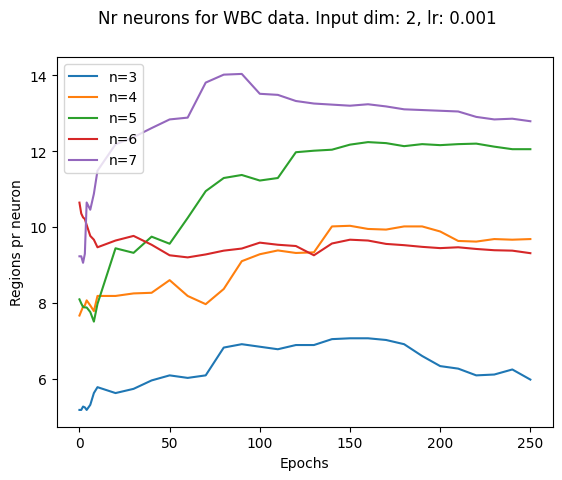

In [56]:
plot_regions_pr_neuron(2, 0.001)

--- Processing Seed 102 (lr=0.01, dim=3, neurons=3) ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...

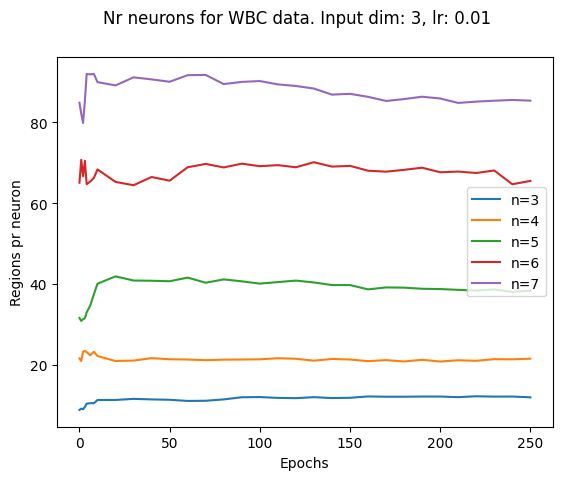

In [57]:
plot_regions_pr_neuron(3, 0.01)

--- Processing Seed 102 (lr=0.001, dim=3, neurons=3) ---
Loaded 114 points. Found 32 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130..

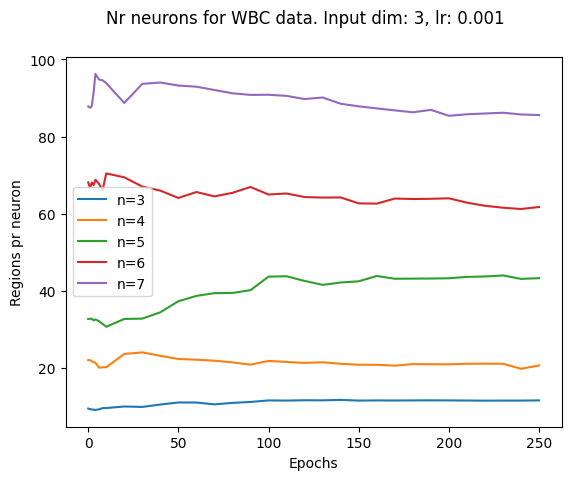

In [58]:
plot_regions_pr_neuron(3, 0.001)